
<h1 style="text-align: center;">Uncovering Netflix’s World: A Deep Dive into the Movies and TV Shows Landscape with Visual Insights


<img src="https://chiswickherald.co.uk/24-05-2023-03-47-00-am-8355141.jpg" alt="Udemy Image" width="850" height="850" style="display: block; margin: auto;">

# Set Up the Environment
- We import **NumPy** for numerical operations, **Pandas** for data manipulation, **Matplotlib** for basic plotting, and **Seaborn** for advanced statistical visualizations.
- These libraries are essential for performing data analysis and generating visualizations in this project.

Additionally, we use the **os** library to interact with the file system and access the input data files. Below, we list all the files available in the `/kaggle/input` directory, which contains the dataset.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed. 
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(f"Setup complete!\nWorking file: {os.path.join(dirname, filename)}")

Setup complete!
Working file: /kaggle/input/netflix-shows/netflix_titles.csv


# ✅✅

# Load & Inspect the Data
This step involves loading the dataset into a Pandas DataFrame and performing an initial inspection to understand its structure and contents. The operations include:
1. Loading the Data
2. Previewing the Data
3. Summarizing the Data
4. Checking the Dataset Size

In [2]:
#1 Read the dataset into a DataFrame
df=pd.read_csv('/kaggle/input/netflix-shows/netflix_titles.csv')

In [3]:
#2 Display the first few rows (head()) to understand its format.
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


OBSERVATION
- The 'director', 'cast' and 'country' columns contain **NaN** values, indicating missing data.
- The 'date_added' column is currently in the format Month Day, Year (e.g., September 25, 2021) but needs to be converted to the standard **ISO 8601 format (YYYY-MM-DD)** for consistency and easier analysis.

In [4]:
#3.1 Check column names, data types, and counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


OBSERVATION
- **.info()** corroborates the presence of missing values and highlights incorrect data types already suggested by **.head()**.
- Additionally, it reveals columns that require **text-based cleaning** (e.g., removing inconsistencies in capitalization, extra spaces, or invalid entries like "Unknown").

In [5]:
#3.2 Get basic statistical summaries 
df.describe(include=['object'])

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


OBSERVATION
- The .describe() output helps reveal *distributions*, *frequencies*, and *patterns* in categorical data, which we can use to formulate relevant, insightful questions to guide our exploratory data analysis (EDA).

In [6]:
#4 See the number of rows and columns
df.shape

(8807, 12)

OBSERVATION
- Based on the output above we can choose appropriate visualizations like histograms, count plots, and box plots to explore **data distributions**. The manageable dataset size allows for efficient analysis of both categorical and numerical features, including **missing data analysis** with heatmaps and **relationships** with scatter plots.

# ✅✅

# Outlier Detection and Handling
Identify and assess any outliers or extreme values that could skew analysis or modeling, particularly in numerical columns.

**Boxplot Visual Inspection**:
- Visual identification of outliers using boxplots.

**Z-score Statistical Approach**:
- Statistical method for detecting outliers by calculating Z-scores.

**Outlier Handling (Optional, based on findings)**:
- Discuss potential methods to handle detected outliers (e.g., removing or capping).

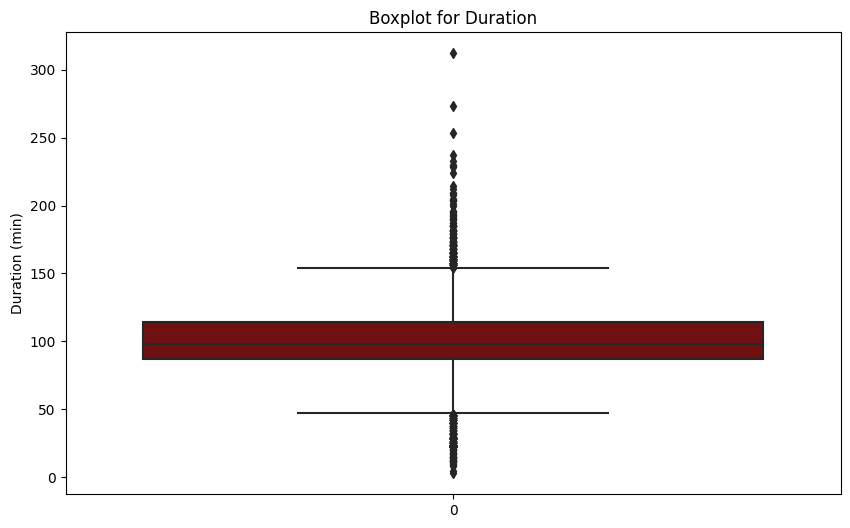

In [9]:
#Boxplot Visual Inspection
movies_df = df.dropna(subset=['duration'], inplace=True)
movies_df = df[df['type'] == 'Movie']
movies_df.loc[:, 'duration'] = movies_df['duration'].str.replace('min', '').astype('int')

plt.figure(figsize=(10, 6))
sns.boxplot(data=movies_df['duration'], color='maroon')
plt.title('Boxplot for Duration')
plt.ylabel('Duration (min)')
plt.show()

**Data Transformation**:

**Observation:**


In [44]:
#Z-Score Statistical Approach
df = df[df['type'] == 'Movie']
df.dropna(subset=['duration'])
#df.loc[:, 'duration'] = df['duration'].astype('int')
df=df.loc[:, 'duration'].astype('int').dtype
df['zscore'] = zscore(df['duration'])
outliers = df[df['zscore'].abs() > 3]

KeyError: 'There are no fields in dtype int64.'

**Data Transformation**:

**Observation:**

# ✅✅

# Exploratory Questions 
💡
1. **Content Trends**
- What are the most common types of content (e.g., Movies vs TV shows)?
2. **Content Distribution**
- What are the top countries contributing to the Netflix library?
- Which countries have the most diverse types of content (based on type and listed_in)?
3. **Director and Cast Insights**
- Which directors or cast members are featured most frequently?
4. **Date Trends Analysis**
- Are there any noticeable spikes or trends in content addition by month or year?
5. **Correlation Between Release Year & Duration**
  - Investigate the relationship between the release year and duration of movies.

OBSERVATION
- After loading and inspecting the Netflix data, we can deduce several exploratory questions that will guide our further analysis. These questions, listed above, will be addressed in subsequent steps of the analysis, helping us uncover insights and trends in the dataset.

# ✅✅

# Data Cleaning
1. Assessing Missing Values
2. Assessing Duplicate Values
3. Handle Data Types
4. Feature Extraction & Removal

In [ ]:
#1.1 Identify columns with missing values
df.isna().sum()

In [ ]:
#1.2 Handle missing values
df.dropna(subset=['date_added','director', 'duration'],inplace =True) 
df = df.fillna('Unknown')

OBSERVATION
- We filled `NaN` values in categorical columns with "Unknown" to preserve valuable content. However, `NaN` values in the `date_added` column were dropped to avoid errors when extracting and converting the month and year to integers.

In [ ]:
#1.3 Validating data completeness post-fill
# If the condition is true, the code proceeds normally. 
# If false, it raises an AssertionError with the message "Data contains missing values".
assert df.isnull().sum().sum() == 0, "Data contains missing values"

In [ ]:
#2 Identify and remove duplicate rows (if any)
df.duplicated().sum()

OBSERVATION
- No further action is required to address duplicate values, as none were found.

In [ ]:
#3 Convert 'date_added' to datetime ensuring invalid values are coerced into NaT instead of raising an error.
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce') 

OBSERVATION
- When converting date_added to datetime, errors were generated because the dates were not in the standard ISO format (YYYY-MM-DD). To tackle this, we used errors='coerce', which **replaced those incorrectly formatted dates with NaT (Not a Time)**, indicating missing or invalid date values.

In [ ]:
df.dropna(subset=['date_added'],inplace =True)

OBSERVATION
- As a result of the previous step, we now have **new missing values (NaT) that need to be dropped** to ensure clean and valid data for further analysis.

In [ ]:
#4.1 Extract year and month into separate columns
df['month_added'] = df['date_added'].dt.month.astype('int')
df['year_added'] = df['date_added'].dt.year.astype('int')

In [ ]:
#4.2 Drop the original 'date_added' column
df.drop(columns=['date_added'])

OBSERVATION:
- We created two new columns, *month_added* and *year_added*, by extracting the month and year from the date_added column. This feature engineering step will help us answer the question: "Are there any noticeable spikes or trends in content addition by month or year?" By analyzing these new columns, we can **identify seasonal patterns and track yearly growth in Netflix's content library**.

# ✅✅

# Univariate Analysis
- **Content Trends**: Visualize the distribution of content types (Movies vs TV shows).
- **Content Distribution**: Create a bar chart to identify top countries contributing to Netflix's library.
- **Director Insights**: Use a bar chart to highlight the most frequently appearing directors.
- **Date Trends Analysis**: Plot the number of titles added by month and year to identify trends over time.

In [ ]:
#Content Trends: Visualize the distribution of content types (Movies vs TV shows) with a bar chart
content_counts = df['type'].value_counts()

content_counts.plot(kind='bar', color=['darkred', 'black'])
plt.title('Distribution of Content Types (Movies vs TV shows)')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
tick_val = [1000, 2000, 3000, 4000, 5000, 6000]
tick_lab = ['1k', '2k', '3k', '4k', '5k', '6k']
plt.yticks(tick_val, tick_lab)
plt.show()

OBSERVATIONS
- A bar plot was chosen because it effectively reveals the relationship between categorical (*Content Type*) and numeric (*Count*) variables.
- The number of movies on Netflix exceeds by a lot that of TV shows, indicating a stronger focus on movies within the platform's library. Regardless, a contributing factor might also be the elimination of missing values.
- This imbalance may reflect *user demand, licensing agreements, or Netflix's strategy* to prioritize movies over TV shows.

In [ ]:
#Content Distribution: Create a bar chart to identify top countries contributing to Netflix's library
country_counts = df['country'].value_counts().head(10)
colors = ['#800020', 'dimgrey', 'darkred', 'red', 'maroon', 'crimson', 'grey', 'white', 'darkgrey']

explode = (0, 0, 0.1,0,0,0,0,0,0,0)
country_counts.plot(
    kind='pie', 
    autopct='%1.1f%%', 
    figsize=(8, 8), 
    colors=colors,
    explode=explode
)
plt.title('Top Contributing Countries to Netflix Library')
plt.ylabel(' ')
plt.show()

OBSERVATION
- The United States, contributing 46.6%, and India, with 16.3%, are the top two countries in the Netflix library. However, a large portion of the data is labeled as "Unknown" due to missing values, which were filled in with the placeholder "Unknown". This **skews the pie chart**, making the analysis *less reliable* since the missing values affect the true distribution of content by country.

In [ ]:
#Director Insights: Use a bar chart to highlight the most frequently appearing directors
director_counts = df['director'].value_counts().head(10)

director_counts.plot(kind='barh', color='darkred')
plt.title('Top 10 Directors by Frequency')
plt.xlabel('Frequency')
plt.ylabel('Director')
plt.xticks(rotation=45)
plt.show()

OBSERVATION
- From the horizontal bar chart, it can be deduced that the presence of a mixture of names indicates a variety of directors in the dataset. Additionally, dropping the NaN values for the director column was essential, as a large proportion of "Unknown" values existed, which could have heavily skewed the analysis and misrepresented the actual distribution of directors. 

In [ ]:
#Date Trends Analysis: Plot the number of titles added by month and year to identify trends over time
#1 Histogram of Months
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df, 
    x='month_added', 
    bins=12, 
    kde=True, 
    edgecolor='black', 
    color='lightcoral', 
    alpha=0.5
)
plt.title('Distribution of Titles Added by Month')
plt.xlabel('Month')
plt.ylabel('Titles')
tick_val = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
tick_lab = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(tick_val, tick_lab, rotation=45)
plt.yticks(rotation=0)
plt.grid(linestyle='--', alpha=0.3)
plt.show()

#Histogram of Years
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df, 
    x='year_added', 
    bins=len(df['year_added'].unique()), 
    kde=True, 
    edgecolor='black', 
    color='maroon', 
    alpha=0.5
)
plt.title('Distribution of Titles Added by Year')
plt.xlabel('Year')
plt.ylabel('Titles')
plt.grid(linestyle='--', alpha=0.3)
plt.show()

**Data Transformations**:
- No data transformations were needed as the histograms were plotted directly using the release_year, year_added and month_added columns.
  
**Observation**:
- By Year: The majority of titles were produced between 2018 and 2020. However, missing values in the data may have skewed this distribution.
- By Month: The distribution of titles shows consistent monthly production, with the fewest titles added in February. This may be due to February being the shortest month, potentially influencing the lower count.

# ✅✅

# Bivariate Analysis:
- **Content vs Country**: Examine the relationship between content type and country.
- **Duration vs Release Year**: Investigate the correlation between content duration and release year (Movies or TV shows).

In [ ]:
#Content vs Country: Examine the relationship between content type and country
top_countries = df['country'].value_counts().head(10).index
filtered_df = df[df['country'].isin(top_countries)]

dark_reds = ['#a8a7a7', '#830909']
plt.figure(figsize=(12, 6))
sns.countplot(
    x='country',
    hue='type',
    data=filtered_df,
    palette=dark_reds
)
plt.title('Distribution of Content Types Across Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.yscale('log')
plt.grid(alpha=0.8)
plt.show()

**Data Transformations**:
- We filtered the dataset to include only the top 10 contributing countries to the Netflix library.
  
**Observation**:
- The United States is the leading producer of movies, with the highest count of movie content.
- Canada produces the least number of TV shows compared to the other sampled countries.

In [ ]:
#Duration vs Type: Investigate the correlation between content duration and type (Movies vs TV shows)
movies_df = df[(df['type'] == 'Movie') & (df['release_year'] != 'Unknown') & (df['duration'] != 'Unknown')]
movies_df = drop
movies_df.loc[:, 'duration'] = movies_df['duration'].str.replace('min', '').astype('int')
movies_df_sample = movies_df.sample(frac=0.1, random_state=50)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='release_year', 
    y='duration', 
    data=movies_df_sample, 
    color='red', 
    alpha=0.3
)
plt.title('Correlation Between Release Year & Movies Duration')
plt.xlabel('Release Year')
plt.ylabel('Duration (min)')
plt.show()

**Data Transformation**:
- Removed rows with "Unknown" values in the type, release_year, and duration columns.
- Converted the duration column from string format (with "min" suffix) to integers.
- Sampled 10% of the data to reduce clutter in the scatter plot.
  
**Observation**:
- The majority of movies are concentrated between 2010 and 2020, with average durations around 100 minutes.

# ✅✅

# Reporting
**Executive Summary**:
- Provide a high-level summary of the key findings from your exploratory analysis.
Highlight the most significant patterns (e.g., most movies are from the US, the peak of content releases between 2018-2020, and regularity in monthly releases).

**Data Preparation & Cleaning**:
- Briefly mention any data cleaning steps you've done (e.g., handling missing values, removing "Unknown", converting duration to integer).
If relevant, note any transformations applied to the data for clarity or analysis purposes.

**Exploratory Data Analysis (EDA) Overview**:
- List the visualizations you created (e.g., histograms, scatter plots, box plots) and explain what you aimed to analyze with each.
Summarize the insights and observations drawn from each plot.
Mention any challenges faced (e.g., skewed results due to missing data, need for sampling).

**Key Insights**:
- Provide a summary of the main findings (e.g., United States produces the most movies, duration of movies clustered between 2010-2020, etc.).
If you did any comparative analysis (e.g., between countries or content types), mention those key takeaways.

**Conclusions**:
-Wrap up by stating the implications of your findings.
If the analysis was for a business problem or any decision-making process, mention how the insights can be applied.

**Future Work (Optional)**:
- If there are areas that could be further investigated (e.g., trends over time, deeper statistical analysis, prediction modeling), mention them.
Recommend steps to improve the analysis or next steps in your workflow.

# ✅✅